# Sentiment Analysis, Semantic Search & LLM for Customer Intelligence

In [456]:
# Display all available queries:
from pathlib import Path
processed_base = Path("data/processed")

available_queries = [
    folder.name
    for folder in processed_base.iterdir()
    if folder.is_dir()
]

print(available_queries)

['alibaba_review', 'dhl_logistik_experiences_erfahrungen', 'etsy_experiences', 'zalando_review']


In [457]:
query_slug = "zalando_review"

In [458]:
import seaborn as sns
import pandas as pd
import numpy as np
import sqlite3
import json
import pandas as pd
from pathlib import Path
import plotly.express as px

In [459]:
conn = sqlite3.connect(
    Path("database") / "youtube_reviews.db"
)

In [460]:
def load_query_data(query_slug, conn):

    videos_df = pd.read_sql(
        """
        SELECT *
        FROM videos
        WHERE query_slug = ?
        """,
        conn,
        params=[query_slug]
    )

    comments_df = pd.read_sql(
        """
        SELECT *
        FROM comments
        WHERE query_slug = ?
        """,
        conn,
        params=[query_slug]
    )

    return videos_df, comments_df

In [461]:
videos_df, comments_df = load_query_data(
    query_slug,
    conn
)

In [462]:
import plotly.express as px

# =========================
# BUILD QUADRANT MAP
# =========================

fig = px.scatter(

    videos_df,

    x="discussion_activation_rate",
    y="controversy_tension_score",

    color="video_type",

    size="log_comment_count",

    hover_data=[
        "title",
        "sentiment",
        "log_like_count",
        "log_comment_count"
    ],

    opacity=0.7,

    title="Discussion Activation vs Controversy Landscape"
)

# =========================
# ADD QUADRANT LINES
# =========================

dar_mean = videos_df[
    "discussion_activation_rate"
].mean()

cts_mean = videos_df[
    "controversy_tension_score"
].mean()

fig.add_vline(
    x=dar_mean,
    line_dash="dash",
    line_color="black"
)

fig.add_hline(
    y=cts_mean,
    line_dash="dash",
    line_color="black"
)

# =========================
# ANNOTATIONS
# =========================

fig.add_annotation(
    x=dar_mean * 1.5,
    y=cts_mean * 1.5,
    text="High Engagement + High Controversy",
    showarrow=False
)

fig.add_annotation(
    x=dar_mean * 0.5,
    y=cts_mean * 0.5,
    text="Low Engagement + Low Controversy",
    showarrow=False
)

# =========================
# LAYOUT
# =========================

fig.update_layout(
    template="plotly_white",
    height=700
)

fig.show()

# Optional:
fig.write_html(
    f"plots/Zalando/DAR_CTS_quadrant_map.html"
)

In [463]:
print(f"At this moment, we have {comments_df.shape[0]} comments which belong to {comments_df["video_id"].nunique()} videos.")

At this moment, we have 258 comments which belong to 29 videos.


## Sentiment Development Over Time

In [464]:
comments_df["published_at"] = pd.to_datetime(
    comments_df["published_at"]
)

In [465]:
weekly_sentiment = (
    comments_df
    .set_index("published_at")
    .resample("W")["sentiment"]
    .mean()
    .reset_index()
)

<Axes: xlabel='published_at', ylabel='sentiment'>

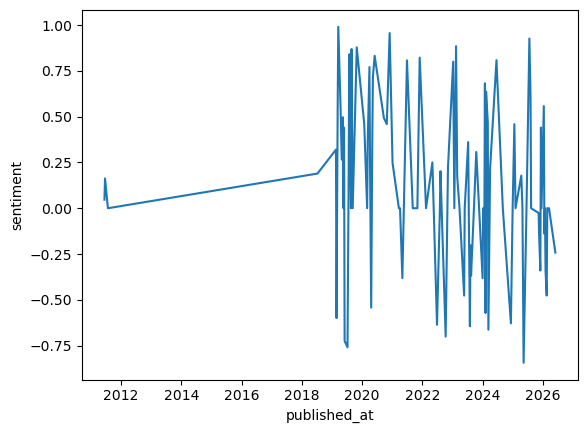

In [466]:
sns.lineplot(
    data=weekly_sentiment,
    x="published_at",
    y="sentiment"
)

## Low-rank visualization of embedding space:

In [390]:
#%pip install umap-learn
import umap.umap_ as umap

In [391]:
comments_semantic = pd.read_sql(
    """
    SELECT
        c.comment_id,
        c.video_id,
        c.text,
        c.query_slug,
        c.sentiment,


        e.embedding_json,

        v.title,
        v.video_type

    FROM comments c

    LEFT JOIN comment_embeddings e
        ON c.comment_id = e.comment_id

    LEFT JOIN videos v
        ON c.video_id = v.video_id

    WHERE c.query_slug = ?
    """,
    conn,
    params=[query_slug]
)

In [392]:
comments_semantic["embedding"] = (
    comments_semantic["embedding_json"]
    .apply(json.loads)
)

In [393]:
embedding_matrix = np.vstack(
    comments_semantic["embedding"]
)

In [394]:
reducer = umap.UMAP(
    n_components=3,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

embedding_3d = reducer.fit_transform(
    embedding_matrix
)

c:\Users\gkahl\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [395]:
comments_semantic["x"] = embedding_3d[:,0]
comments_semantic["y"] = embedding_3d[:,1]
comments_semantic["z"] = embedding_3d[:,2]

In [396]:
fig = px.scatter_3d(
    comments_semantic,

    x="x",
    y="y",
    z="z",

    color="video_type",

    hover_data=[
        "text",
        "title",
        "sentiment"
    ],

    opacity=0.7,

    title="3D Semantic Map of YouTube Comments"
)

fig.write_html(
    "plots/Alibaba/semantic_map.html"
)

fig.show()

## Semantic Comment Clustering using HDBSCAN

In [397]:
#%pip install hdbscan

In [398]:
import hdbscan

In [399]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5,
    min_samples=3
)

comments_semantic["cluster"] = clusterer.fit_predict(
    embedding_matrix
)

In [400]:
cluster_centers = (
    comments_semantic
    .groupby("cluster")[["x", "y", "z"]]
    .mean()
    .reset_index()
)

In [401]:
cluster_centers = cluster_centers[
    cluster_centers["cluster"] != -1
]

In [402]:
fig = px.scatter_3d(
    comments_semantic,

    x="x",
    y="y",
    z="z",

    color="video_type",

    hover_data=[
        "text",
        "title",
        "cluster",
        "sentiment"
    ],

    opacity=0.6
)

In [403]:
fig.add_scatter3d(
    x=cluster_centers["x"],
    y=cluster_centers["y"],
    z=cluster_centers["z"],

    mode="markers+text",

    marker=dict(
        size=10,
        color="black"
    ),

    text=cluster_centers["cluster"],

    name="Cluster Centers"
)

fig.write_html(
    "plots/Alibaba/semantic_clusters.html"
)

fig.show()

In [404]:
# Look at cluster/noise-distribution:
comments_semantic["cluster"].value_counts()

cluster
-1     1211
 13     799
 2       73
 5       27
 12      16
 11      12
 1       11
 3       10
 6        9
 4        8
 14       8
 7        7
 8        7
 10       6
 9        5
 0        5
Name: count, dtype: int64

In [405]:
for cluster_id in sorted(comments_semantic["cluster"].unique()):

    print(f"\nCLUSTER {cluster_id}")

    sample = comments_semantic[
        comments_semantic["cluster"] == cluster_id
    ]["text"].head(5)

    for text in sample:
        print("-", text[:200])


CLUSTER -1
- I've only received decent items in the first order....after that it's mouldy, faulty, roughly made, wrong colours....it's all junk for the tip after a few orders....and some sellers  can be difficult.
- I would argue honesty is more important than faking confidence that you know what you're doing.
Be respectful but also have the energy of "don't you dare take advantage of me or YOU lose ME". Build up
- What about if you want to buy a bike or a car from them I was at work
- I live in Korea and I bought a machine that costs around 600 USD but they sent sth else that’s not even worth the same value. Now they’re not even replying back but I already transferred my money to t
- Man i hope this really helps me start my dream of running a hydroponics store 😮😮❤

CLUSTER 0
- Man! There are only 195 countries in the world.
- "in more then 200 countries"
 *checks google*
195 countries
- How can it have operations in 200 countries when there are total of 195 countries??
- Ummmm there’

In [406]:
duplicates = pd.read_sql(
    """
    SELECT
        video_id,
        query_slug,
        COUNT(*) as n

    FROM videos

    GROUP BY video_id, query_slug

    HAVING COUNT(*) > 1
    """,
    conn
)

duplicates.head()

,video_id,query_slug,n


In [407]:
comments_df.shape

(258, 18)

In [ ]:
# Code snippets for deleting duplicates in case of mistaken addition to  sqlite:
#cursor = conn.cursor()

#cursor.execute(
#    """
#    DELETE FROM videos
#
#    WHERE rowid NOT IN (
#        SELECT MIN(rowid)
#
#        FROM videos
#
#        GROUP BY video_id, query_slug
#    )
#    """
#)

#conn.commit()

In [ ]:
#cursor.execute(
#    """
#    DELETE FROM video_description_embeddings
#
#    WHERE rowid NOT IN (
#        SELECT MIN(rowid)
#
#        FROM video_description_embeddings
#
#        GROUP BY video_id
#    )
#    """
#)

#conn.commit()

## Incorporate an LLM Chatbot using RAG technology to answer questions on the data basis

User chooses query_slug  
        ↓  
User poses question  
        ↓  
Embed question  
        ↓  
Similarity Search in SQLite-Data  
        ↓  
Top-k relevant comments/videos  
        ↓  
context for GPT-4o-mini  
        ↓  
Answer + Sources

### Querying:

In [ ]:
query_slug = "zalando_review" # In Streamlit, we will select this using buttons etc.
# 'alibaba_review', 'dhl_logistik_experiences_erfahrungen', 'etsy_experiences', 'zalando_review'
# What are the main complaints and pain points for customers of Alibaba?
# What are the main complaints and pain points for sellers and buyers on Etsy? What are popular views held about the platform?
# What are the main complaints and pain points for customers of DHL? What is said about working conditions at DHL?
user_question = "What are the main complaints and pain points for Zalando customers? What are popular views held about the platform and is there feedback for improvement?" # This is what the user actually inputs

In [282]:
from openai import OpenAI
import numpy as np
import os
import json

In [283]:
import os
from dotenv import load_dotenv
# Load and proceed with the current API keys
load_dotenv(override=True)

True

In [284]:
# Initialize OpenAI client
client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY")
)

### Embed user question:

In [285]:
response = client.embeddings.create(
    model="text-embedding-3-small",
    input=user_question
)

question_embedding = response.data[0].embedding

### Retrieve all comments related to the query_slug/subject ("Zalando")

In [286]:
comments_rag = pd.read_sql(
    """
    SELECT
        c.comment_id,
        c.text,
        c.sentiment,
        c.video_type,

        e.embedding_json

    FROM comments c

    LEFT JOIN comment_embeddings e
        ON c.comment_id = e.comment_id

    WHERE c.query_slug = ?
    """,
    conn,
    params=[query_slug]
)

In [287]:
# Convert comments from json
comments_rag["embedding"] = (
    comments_rag["embedding_json"]
    .apply(json.loads)
)

### Calculate similarity matrix

In [288]:
from sklearn.metrics.pairwise import cosine_similarity

In [289]:
embedding_matrix = np.vstack(
    comments_rag["embedding"]
)

In [290]:
similarities = cosine_similarity(
    [question_embedding],
    embedding_matrix
)[0]

In [291]:
comments_rag["similarity"] = similarities

### Select the top 10 comments as context for GPT

In [292]:
top_comments = (
    comments_rag
    .sort_values(
        "similarity",
        ascending=False
    )
    .head(10)
)

In [293]:
context = "\n\n".join(
    top_comments["text"].tolist()
)

### GPT prompt and reply

In [294]:
chat_response = client.chat.completions.create(
    model="gpt-4o-mini",

    messages=[
        {
            "role": "system",
            "content":
            """
            You are a customer intelligence analyst.

            Answer questions based ONLY on the retrieved YouTube comments and metadata.
            Summarize recurring themes and mention sentiment patterns.
            Identify:
            
                - recurring complaints
                - customer sentiment
                - product/service issues
                - positive feedback patterns

            Do not invent information.
            """
        },

        {
            "role": "user",
            "content":
            f"""
            USER QUESTION:
            {user_question}

            COMMENTS:
            {context}
            """
        }
    ]
)

In [295]:
print(
    chat_response.choices[0].message.content
)

Based on the retrieved YouTube comments regarding Zalando, here are the recurring themes and sentiment patterns:

### Recurring Complaints:
1. **Credibility Concerns**: Some users expressed doubts about the legitimacy of Zalando, with comments labeling it a "scam site" and questioning whether they sell original or fake products.
2. **Service and Customer Experience**: A negative sentiment is evident in comments describing Zalando as a "Saftladen" (nonsense shop), indicating dissatisfaction with the company's operations or customer service.
3. **Charges and Fees**: There were complaints about additional charges, specifically the 0.25 EUR cent fee applied to orders for environmental reasons, which some users view as an unnecessary financial burden and indicative of insincerity regarding environmental efforts.

### Customer Sentiment:
- **Negative Sentiment**: Many comments reflect a critical or frustrated viewpoint towards Zalando’s practices, especially regarding perceived dishonesty an

## Zalando Example RAG Output

Based on the retrieved YouTube comments regarding Zalando, here are the recurring themes and sentiment patterns:

### Recurring Complaints:
1. **Credibility Concerns**: Some users expressed doubts about the legitimacy of Zalando, with comments labeling it a "scam site" and questioning whether they sell original or fake products.
2. **Service and Customer Experience**: A negative sentiment is evident in comments describing Zalando as a "Saftladen" (nonsense shop), indicating dissatisfaction with the company's operations or customer service.
3. **Charges and Fees**: There were complaints about additional charges, specifically the 0.25 EUR cent fee applied to orders for environmental reasons, which some users view as an unnecessary financial burden and indicative of insincerity regarding environmental efforts.

### Customer Sentiment:
- **Negative Sentiment**: Many comments reflect a critical or frustrated viewpoint towards Zalando’s practices, especially regarding perceived dishonesty and additional fees.
- **Mixed to Positive Sentiment**: A few users express a love for shopping on Zalando, appreciating its product selection and style offerings, indicating a contingent of satisfied customers.

### Product/Service Issues:
- **Verification of Product Authenticity**: Customers are concerned about the authenticity of the products sold on the platform, particularly with footwear.
- **Perceptions of Ethical Practices**: There is discontent regarding the environmental fees charged, suggesting a disconnect between customer expectations and Zalando's policies.

### Positive Feedback Patterns:
- **Product Range and Appeal**: Despite the criticisms, some users praised Zalando's inventory, particularly the aesthetic appeal of the items available.
- **General Satisfaction with Updates**: A couple of comments show appreciation for Zalando updates, pointing to engagement with the brand’s communication efforts.

### Suggestions for Improvement:
The comments hint at a need for Zalando to enhance transparency regarding product authenticity and to reassess their fee structures related to environmental initiatives to address customer concerns effectively.

## Alibaba Example RAG Output

**Recurring Complaints and Customer Pain Points about Alibaba:**

1. **Scams and Fraudulent Sellers:** A significant number of comments highlight the prevalence of scammers on Alibaba. Customers express frustration with sellers who misrepresent their products and services. There are multiple references to losing money to fraudulent shipping scams and being scammed by sellers.

2. **Poor Customer Support:** Many users report dissatisfaction with Alibaba's complaint process. They feel that the platform does not adequately support buyers who fall victim to scams and lacks accountability. Common sentiments include claims that it is difficult to get resolutions for issues faced and complaints about unhelpful responses from customer service.

3. **Negative Seller Interactions:** Comments indicate that many sellers behave disrespectfully towards customers, often pressuring them for payments or acting aggressively. Instances of harassment from sellers who refuse to resolve issues have also been reported, contributing to customer dissatisfaction.

4. **Accountability and Trust Issues:** Customers express distrust in the verification process of suppliers on Alibaba, questioning the legitimacy of "verified" sellers. There are complaints regarding the platform's failure to take action against sellers who have been reported, which exacerbates feelings of vulnerability and insecurity for buyers.

**Customer Sentiment:**

- The overall sentiment expressed in the comments is **largely negative**, with many users advising against using Alibaba due to their negative experiences.
- Comments reflect a sense of betrayal and frustration from customers who feel they have lost both money and trust in the platform.

**Product/Service Issues:**

- Major issues mentioned include difficulties in obtaining tracking information for shipments, lack of follow-up from Alibaba after complaints are filed, and intimidating behavior from sellers.

**Positive Feedback Patterns:**

- There are no positive feedback patterns observed in the comments retrieved; the overwhelming focus is on complaints and negative experiences with Alibaba.

## DHL Example RAG Output

### Recurring Complaints
1. **Delivery Issues**: A significant number of comments highlight problems with parcel delivery, such as late deliveries, packages being left unattended outside, and poor communication regarding delivery status.
2. **Customer Service Frustration**: Many users express difficulty in reaching DHL for support, citing unhelpful automated answering systems and inefficient online forms.
3. **Work Conditions**: Commenters frequently mention the harsh working conditions for delivery staff, emphasizing the physical demands of the job and the inadequate pay compared to workload.

### Customer Sentiment
- **Negative Sentiment**: The overarching sentiment is largely negative, with comments reflecting frustration over delivery inefficiencies and poor customer service experiences. Phrases like "very bad services" and "the worse ever" illustrate dissatisfaction.
- **Empathy for Workers**: Despite the complaints, there’s a recurring theme of respect for the delivery workers facing tough conditions, as several comments display understanding of their challenges.

### Product/Service Issues
- **Delivery Reliability**: Issues with delivery reliability, such as items not being delivered when promised or packages being stolen after being left outside, are common pain points.
- **Customer Support Accessibility**: Many users report challenges in accessing appropriate customer support, indicating a gap in customer service effectiveness.

### Positive Feedback Patterns
- **Respect for Delivery Staff**: There are positive sentiments expressed toward the delivery staff, acknowledging the hard work and challenges they face, especially during high-demand periods like the holiday season. 
- **Desire to Work for DHL**: Some individuals express eagerness to work for DHL, indicating that despite complaints, there are still those who view employment with the company positively as a job opportunity.

In summary, complaints primarily revolve around delivery reliability and customer service issues, while there is some positive recognition of the delivery workers’ efforts amidst the challenges they encounter.

## Etsy Example RAG Output

Based on the retrieved YouTube comments, several recurring themes and sentiment patterns emerge concerning the experiences of sellers and buyers on Etsy. 

### Recurring Complaints:
1. **Payment Issues for New Sellers**: New sellers express frustration with the payment handling process, feeling it is unfair and punitive toward honest sellers.
2. **High Fees and Complicated Structure**: Numerous comments mention that Etsy's fees are excessive and complicated, making it difficult for sellers to profit from their sales.
3. **Allowing Resellers and Knockoffs**: Sellers report being frustrated with the presence of mass-produced and knockoff items on the platform, which they feel undermines the appeal of unique, handmade products.
4. **Poor Customer Service**: Comments highlight dissatisfaction with Etsy's customer service, with some sellers feeling unsupported when dealing with issues.
5. **Inconsistent Policy Enforcement**: Sellers express concern about arbitrary enforcement of policies, where products are banned without recourse, leading to potential harm to their businesses.

### Customer Sentiment:
- Sentiment is primarily **negative**, with many sellers feeling disenfranchised, unsupported, and pushed out due to Etsy's policy changes. 
- Some comments reflect a **bittersweet nostalgia** for Etsy's original purpose as a marketplace for handmade goods, illustrating disappointment over its evolution.

### Product/Service Issues:
1. **Algorithmic Promotion of Trends**: Sellers claim that Etsy's promotional focus on narrow trends alienates diverse product offerings, driving away potential customers.
2. **Poor User Experience**: New users report challenges navigating the platform and app, leading to a feeling of disorganization and frustration.
3. **Oversaturation of Products**: Some sellers share experiences of their unique products being lost among a sea of mass-produced items, decreasing visibility and sales.

### Positive Feedback Patterns:
- A few comments reflect appreciation for Etsy's initial concept and the convenience it offered when starting small businesses, especially regarding shipping, listing, and tax handling.
- Notably, sellers who have transitioned to developing independent websites express satisfaction with alternatives to Etsy, highlighting growth and positive experiences elsewhere.

### Feedback for Improvement:
- Many commenters suggest that Etsy should return to its roots by prioritizing handmade, unique, and quality products over mass-produced items.
- There are calls for improved customer service and better communication with sellers.
- Some want a more balanced approach to featured products that respects the diversity of offerings on the platform, beyond just current fleeting trends.

Overall, the comments reflect significant concern among sellers regarding the direction Etsy has taken, with a strong desire for reform that would favor genuine artisans and creators.